In [31]:
import pandas as pd
import requests
import numpy as np
from bs4 import BeautifulSoup

In [32]:
url='https://www.myntra.com/women-kurtas-kurtis-suits'
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml"
}

session = requests.Session()
print("starting")
kurtis = session.get(url,headers=headers,timeout=15)

print("done")
print(kurtis.status_code)

starting
done
200


In [33]:
soup= BeautifulSoup(kurtis.text,'lxml')

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Shop for Women Kurtas, Suits &amp; Kurtis Online in India | Myntra
  </title>
  <meta content="#fffff" name="theme-color"/>
  <link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/>
  <link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/>
  <link href="https://www.facebook.com" rel="dns-prefetch preconnect"/>
  <link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/>
  <link href="/manifest.json" rel="manifest"/>
  <link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/>
  <link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="apple
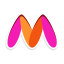

In [34]:
print(soup.prettify())

In [35]:
from selenium import webdriver
from bs4 import BeautifulSoup
import time
driver= webdriver.Chrome()

url = "https://www.myntra.com/women-kurtas-kurtis-suits"
driver.get(url)

time.sleep(10)
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

items= soup.find_all('li',class_='product-base')
print(len(items))

50


In [36]:
print(items[0].prettify())

<li class="product-base" id="34925185">
 <div class="product-thumbShim">
 </div>
 <div class="product-ratingsContainer">
  <span>
   4
  </span>
  <span class="myntraweb-sprite product-starIcon index-productRatingsGoodIcon sprites-productRatingsGoodIcon">
  </span>
  <div class="product-ratingsCount">
   <div class="product-separator">
    |
   </div>
   <!-- react-text: 371 -->
   546
   <!-- /react-text -->
  </div>
 </div>
 <a data-refreshpage="true" href="kurta-sets/sangria/sangria-women-ethnic-motifs-embroidered-cotton-kurta-with-trousers--dupatta/34925185/buy" style="display: block;" target="_blank">
  <div class="product-imageSliderContainer">
   <div class="product-sliderContainer" style="display: block;">
    <div style="background: rgb(255, 242, 223);">
     <div style="height: 280px; width: 100%;">
      <picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;">
       <source srcset="
    https://assets.myntassets.com/f_webp,dpr_1.

In [37]:
title=[]
rating=[]
rating_count=[]
brand=[]
price=[]
image_urls=[]
size=[]

for i in items:

    t = i.find('h4', class_='product-product')
    title.append(t.text.strip() if t else None)

    r = i.find('div', class_='product-ratingsContainer')
    rating.append(r.text.strip() if r else None)

    rc = i.find('div', class_='product-ratingsCount')
    rating_count.append(rc.text.strip() if rc else None)

    b = i.find('h3', class_='product-brand')
    brand.append(b.text.strip() if b else None)

    s = i.find('h4', class_='product-sizes')
    size.append(s.text.strip() if s else None)

    p = i.find('div', class_='product-price')
    price.append(p.text.strip() if p else None)

    img = i.find("img")
    if img:
        image_urls.append(img.get("src"))
    else:
        image_urls.append(None)

In [38]:
d= {'title':title, 'brand':brand, 'rating':rating, 'price':price, 'size':size, 'rating_count': rating_count, 'image_url':image_urls}

In [39]:
df_kurtis=pd.DataFrame(d)

In [40]:
print(df_kurtis.shape)

(50, 7)


In [41]:
df_kurtis["rating"] = df_kurtis["rating"].str.split("|").str[0]
df_kurtis["rating_count"] = df_kurtis["rating_count"].str.split("|").str[1]

In [42]:
df_kurtis["size"] = df_kurtis["size"].str.split(":").str[1]
df_kurtis["current_price"] = (
    df_kurtis["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*(\d+)')
)
df_kurtis["original_price"] = (
    df_kurtis["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*\d+Rs\.\s*(\d+)')
)
df_kurtis["discount"] = (
    df_kurtis["price"]
    .astype(str)
    .str.extract(r'\((.*?)\)')
)
df_kurtis["category"]= 'kurtis'

In [43]:
df_kurtis.head()

,title,brand,rating,price,size,rating_count,image_url,current_price,original_price,discount,category
0,Women Embroidered Kurta Set,Sangria,4,Rs. 1342Rs. 5599(Rs. 4257 OFF),3XL,546,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1342,5599,Rs. 4257 OFF,kurtis
1,Printed Mandarin Collar Kurta,Sangria,4.3,Rs. 645Rs. 3799(83% OFF),M,36,"https://assets.myntassets.com/dpr_2,q_60,w_210...",645,3799,83% OFF,kurtis
2,Maternity ALine Kurta Pant Set,House Of Zelena,4.2,Rs. 1931Rs. 3799(49% OFF),M,52,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1931,3799,49% OFF,kurtis
3,Women Printed Kurta with Palazzos,Keitra,4.5,Rs. 452Rs. 2999(85% OFF),S,7.8k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",452,2999,85% OFF,kurtis
4,Women Embroidered Kurta with Palazzos With Dup...,SOURAGYA,None,Rs. 1623Rs. 5799(Rs. 4176 OFF),XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1623,5799,Rs. 4176 OFF,kurtis


In [44]:
df_kurtis.isnull().sum()

title              0
brand              0
rating            13
price              0
size               0
rating_count      13
image_url          1
current_price      0
original_price     0
discount           0
category           0
dtype: int64

In [45]:
df_kurtis.drop(columns=["price"], inplace=True)

In [46]:
product_url = []
from urllib.parse import urljoin
for i in items:
    
    a = i.find("a")
    
    if a and a.get("href"):
        link = urljoin("https://www.myntra.com", a["href"])
    else:
        link = None

    product_url.append(link)

In [47]:
df_kurtis['product_url']= product_url

In [48]:
df_kurtis_copy= df_kurtis.copy()

In [49]:
def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_kurtis["rating_count"] = df_kurtis["rating_count"].apply(convert_count)

In [50]:
df_kurtis.sample(5)

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
25,Floral Printed Anarkali Kurta,Sa Rasa,3.9,3XL,7300.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",497,2199,77% OFF,kurtis,https://www.myntra.com/kurtas/sa+rasa/sa-rasa-...
49,Floral Printed Anarkali Kurta,Anouk Mirage,None,XL,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",693,1999,65% OFF,kurtis,https://www.myntra.com/kurtas/anouk+mirage/ano...
43,Women Embroidered Kurta with Trousers With Dup...,Keitra,4.3,S,5800.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",780,4999,84% OFF,kurtis,https://www.myntra.com/kurta-sets/keitra/keitr...
29,Women Embroidered Kurta with Sharara With Dupatta,TWINS LADY,4.8,S,17.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1630,4999,67% OFF,kurtis,https://www.myntra.com/kurta-sets/twins+lady/t...
28,Women Embroidered Kurta with Palazzos With Dup...,SOURAGYA,None,XL,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1623,5799,Rs. 4176 OFF,kurtis,https://www.myntra.com/kurta-sets/souragya/sou...


In [51]:
df_kurtis["rating"] = pd.to_numeric(df_kurtis["rating"], errors="coerce")
df_kurtis["current_price"] = pd.to_numeric(df_kurtis["current_price"], errors="coerce")
df_kurtis["original_price"] = pd.to_numeric(df_kurtis["original_price"], errors="coerce")

In [52]:
df_kurtis["rating_count"] = df_kurtis["rating_count"].fillna(0).astype(int)

In [53]:
df_kurtis["original_price"] = (
    df_kurtis["original_price"]
    .fillna(0)
    .astype(int)
)

In [54]:
df_kurtis["discount_percent"] = (
    (
        df_kurtis["original_price"] -
        df_kurtis["current_price"]
    )
    / df_kurtis["original_price"]
) * 100

In [55]:
df_kurtis["discount_percent"] = (
    df_kurtis["discount_percent"]
    .round(2)
)

In [56]:
df_kurtis = df_kurtis.drop("discount", axis=1)

In [57]:
df_kurtis['current_price']=df_kurtis['current_price'].astype(float)

In [58]:
df_kurtis['original_price']= df_kurtis['original_price'].astype(float)

In [59]:
df_kurtis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             50 non-null     object 
 1   brand             50 non-null     object 
 2   rating            37 non-null     float64
 3   size              50 non-null     object 
 4   rating_count      50 non-null     int64  
 5   image_url         49 non-null     object 
 6   current_price     50 non-null     float64
 7   original_price    50 non-null     float64
 8   category          50 non-null     object 
 9   product_url       50 non-null     object 
 10  discount_percent  50 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ KB


In [60]:
df_kurtis.isnull().sum()

title                0
brand                0
rating              13
size                 0
rating_count         0
image_url            1
current_price        0
original_price       0
category             0
product_url          0
discount_percent     0
dtype: int64

In [61]:
df_kurtis.to_csv("looped_kurtis_data.csv", index=False)